<a href="https://colab.research.google.com/github/robitussin/CCDATSCL_EXERCISES/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [82]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [83]:
import os
import pandas as pd

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
print("Files in dataset directory:", contents)

mydataset = os.path.join(path, "full_grouped.csv")
print("Loading dataset from:", mydataset)

df = pd.read_csv(mydataset)


True
Files in dataset directory: ['covid_19_clean_complete.csv', 'country_wise_latest.csv', 'day_wise.csv', 'usa_county_wise.csv', 'worldometer_data.csv', 'full_grouped.csv']
Loading dataset from: /kaggle/input/corona-virus-report/full_grouped.csv


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [85]:
df.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [86]:
df.query("`Country/Region` == 'Philippines'")

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
133,2020-01-22,Philippines,0,0,0,0,0,0,0,Western Pacific
320,2020-01-23,Philippines,0,0,0,0,0,0,0,Western Pacific
507,2020-01-24,Philippines,0,0,0,0,0,0,0,Western Pacific
694,2020-01-25,Philippines,0,0,0,0,0,0,0,Western Pacific
881,2020-01-26,Philippines,0,0,0,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
34354,2020-07-23,Philippines,74390,1871,24383,48136,2121,28,760,Western Pacific
34541,2020-07-24,Philippines,76444,1879,24502,50063,2054,8,119,Western Pacific
34728,2020-07-25,Philippines,78412,1897,25752,50763,1968,18,1250,Western Pacific
34915,2020-07-26,Philippines,80448,1932,26110,52406,2036,35,358,Western Pacific


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

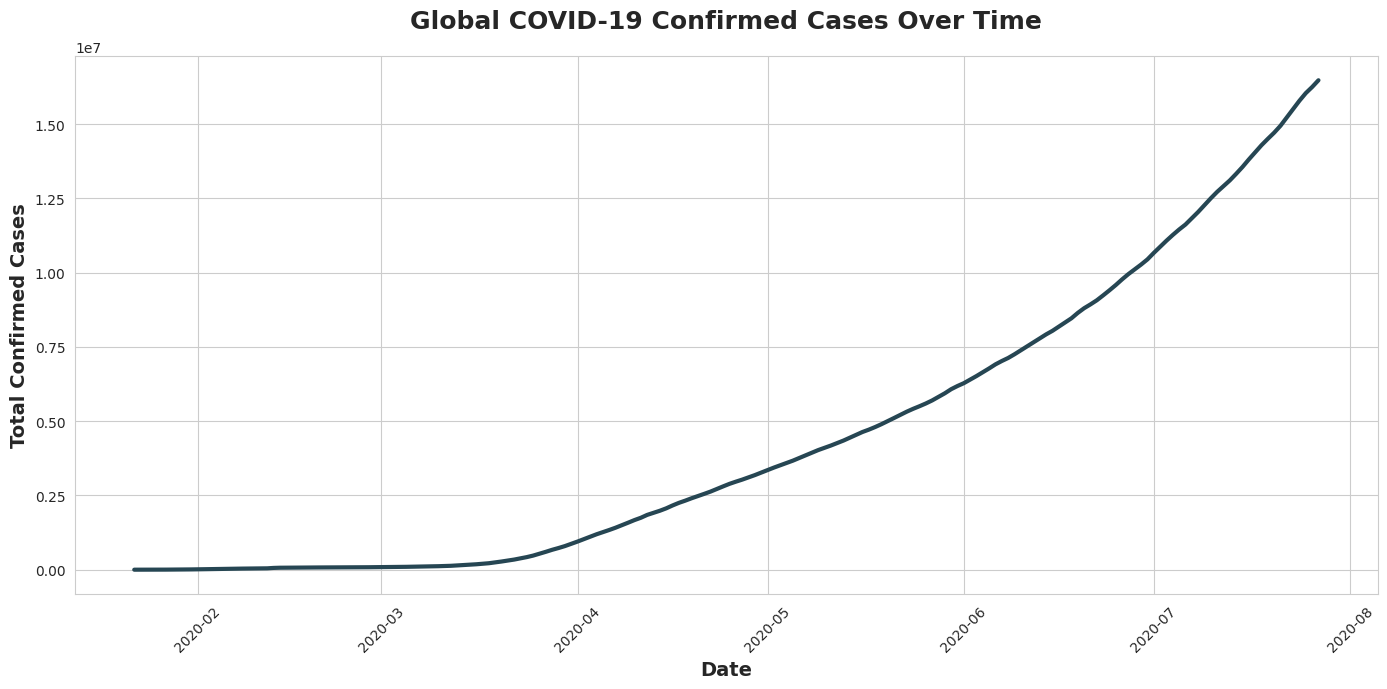

First recorded date: 2020-01-22
Last recorded date: 2020-07-27
Total confirmed cases: 16,480,485


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate global confirmed cases by date
global_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# Create line chart using seaborn
plt.figure(figsize=(14, 7))
sns.lineplot(data=global_cases, x='Date', y='Confirmed', linewidth=3, color='#264653')
plt.title('Global COVID-19 Confirmed Cases Over Time', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Total Confirmed Cases', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistics
print(f"First recorded date: {global_cases['Date'].min().strftime('%Y-%m-%d')}")
print(f"Last recorded date: {global_cases['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total confirmed cases: {global_cases['Confirmed'].max():,}")

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

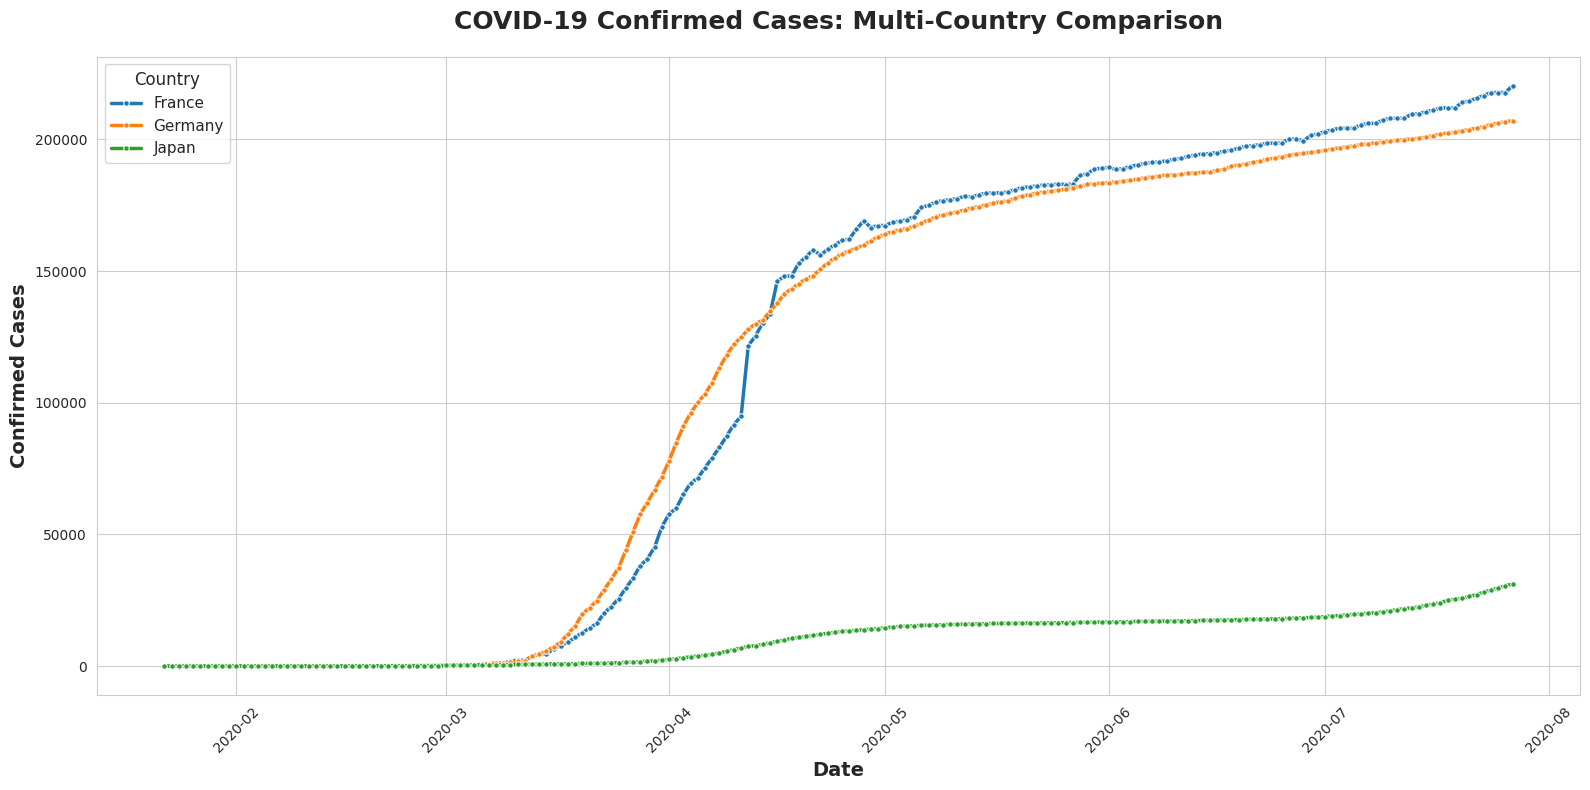

In [88]:
# Select three countries for comparison
comparison_countries = ['France', 'Germany', 'Japan']

# Filter data for selected countries
filtered_df = df[df['Country/Region'].isin(comparison_countries)].copy()
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'])

# Aggregate by date and country
country_trends = filtered_df.groupby(['Date', 'Country/Region'])['Confirmed'].sum().reset_index()

# Create visualization using seaborn
plt.figure(figsize=(16, 8))
sns.lineplot(data=country_trends, x='Date', y='Confirmed', hue='Country/Region',
            linewidth=2.5, marker='o', markersize=4)
plt.title('COVID-19 Confirmed Cases: Multi-Country Comparison',
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Confirmed Cases', fontsize=14, fontweight='bold')
plt.legend(title='Country', title_fontsize=12, fontsize=11, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

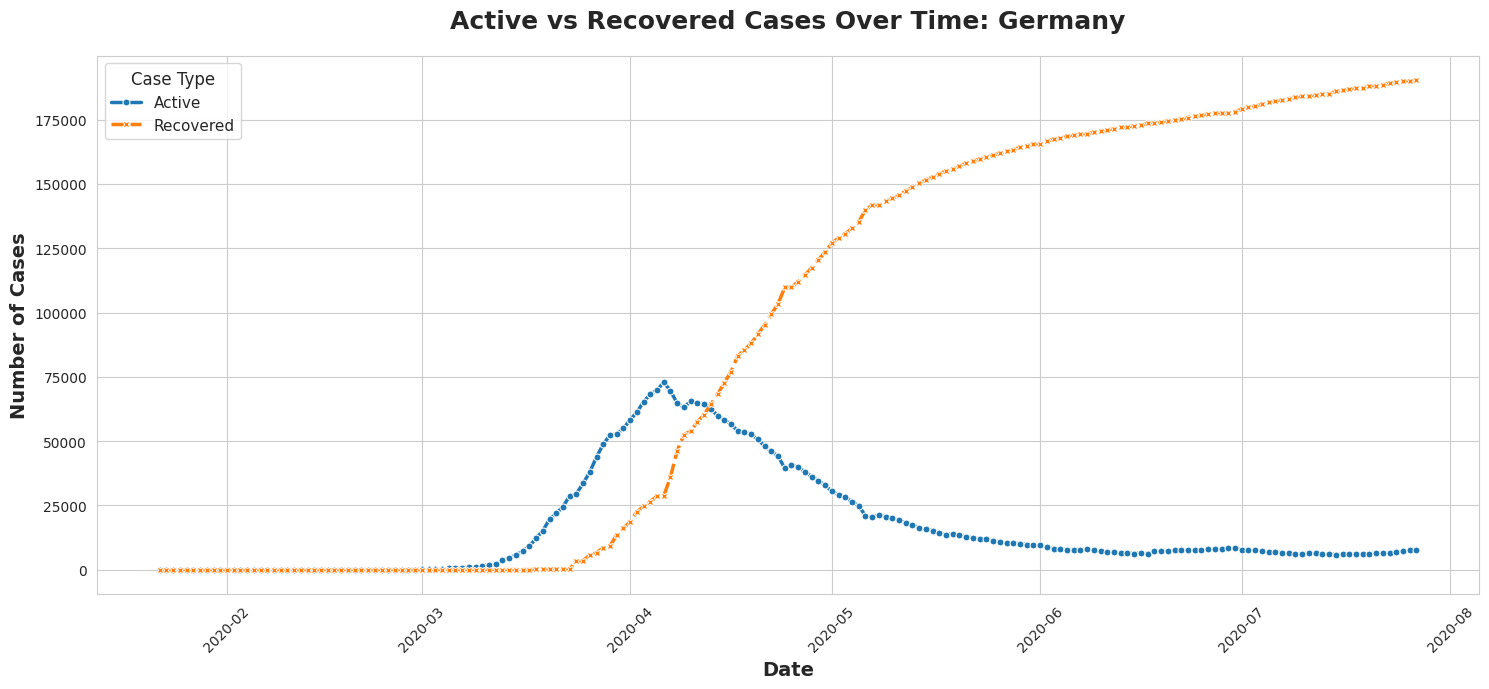

In [89]:
# Select Germany for analysis
analysis_country = 'Germany'

# Filter data for Germany
germany_df = df[df['Country/Region'] == analysis_country].copy()
germany_df['Date'] = pd.to_datetime(germany_df['Date'])

# Aggregate Active and Recovered cases by date
germany_aggregated = germany_df.groupby('Date').agg({
    'Active': 'sum',
    'Recovered': 'sum'
}).reset_index()

# Reshape data for seaborn
germany_melted = germany_aggregated.melt(id_vars='Date',
                                         value_vars=['Active', 'Recovered'],
                                         var_name='Case Type', value_name='Cases')

# Create visualization
plt.figure(figsize=(15, 7))
sns.lineplot(data=germany_melted, x='Date', y='Cases', hue='Case Type',
            linewidth=2.5, style='Case Type', markers=True, markersize=5)
plt.title(f'Active vs Recovered Cases Over Time: {analysis_country}',
         fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Number of Cases', fontsize=14, fontweight='bold')
plt.legend(title='Case Type', title_fontsize=12, fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

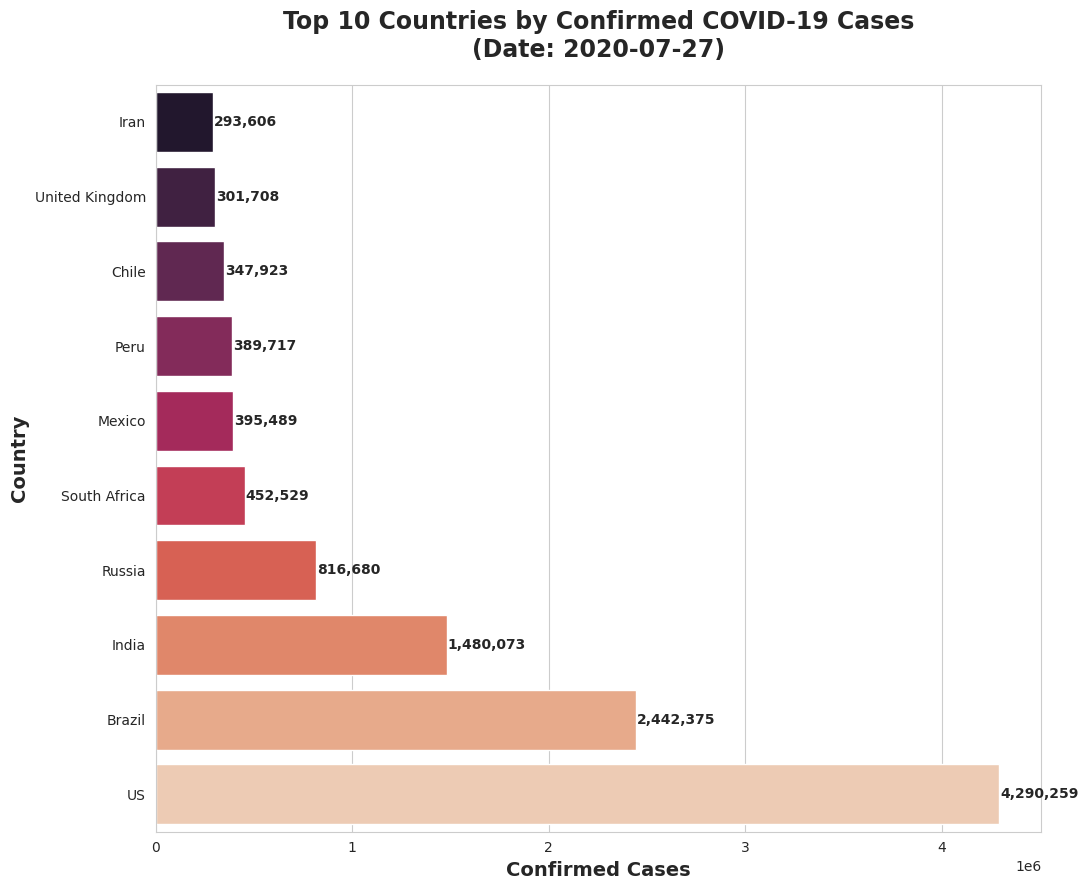

In [90]:
# Select latest date
analysis_date = df['Date'].max()

# Filter data for selected date
date_filtered = df[df['Date'] == analysis_date]

# Aggregate by country
country_summary = date_filtered.groupby('Country/Region')['Confirmed'].sum().reset_index()

# Get top 10 countries
top_10_countries = country_summary.nlargest(10, 'Confirmed').sort_values('Confirmed')

# Create bar chart using seaborn
plt.figure(figsize=(11, 9))
sns.barplot(data=top_10_countries, y='Country/Region', x='Confirmed',
           palette='rocket', orient='h', hue='Country/Region', legend=False)
plt.title(f'Top 10 Countries by Confirmed COVID-19 Cases\n(Date: {analysis_date.strftime('%Y-%m-%d')})',
         fontsize=17, fontweight='bold', pad=20)
plt.xlabel('Confirmed Cases', fontsize=14, fontweight='bold')
plt.ylabel('Country', fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(top_10_countries.iterrows()):
    plt.text(row['Confirmed'] + 5000, i, f"{int(row['Confirmed']):,}",
            va='center', fontsize=10, fontweight='bold') # Removed 'pad' and adjusted x position

plt.tight_layout()
plt.show()

5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

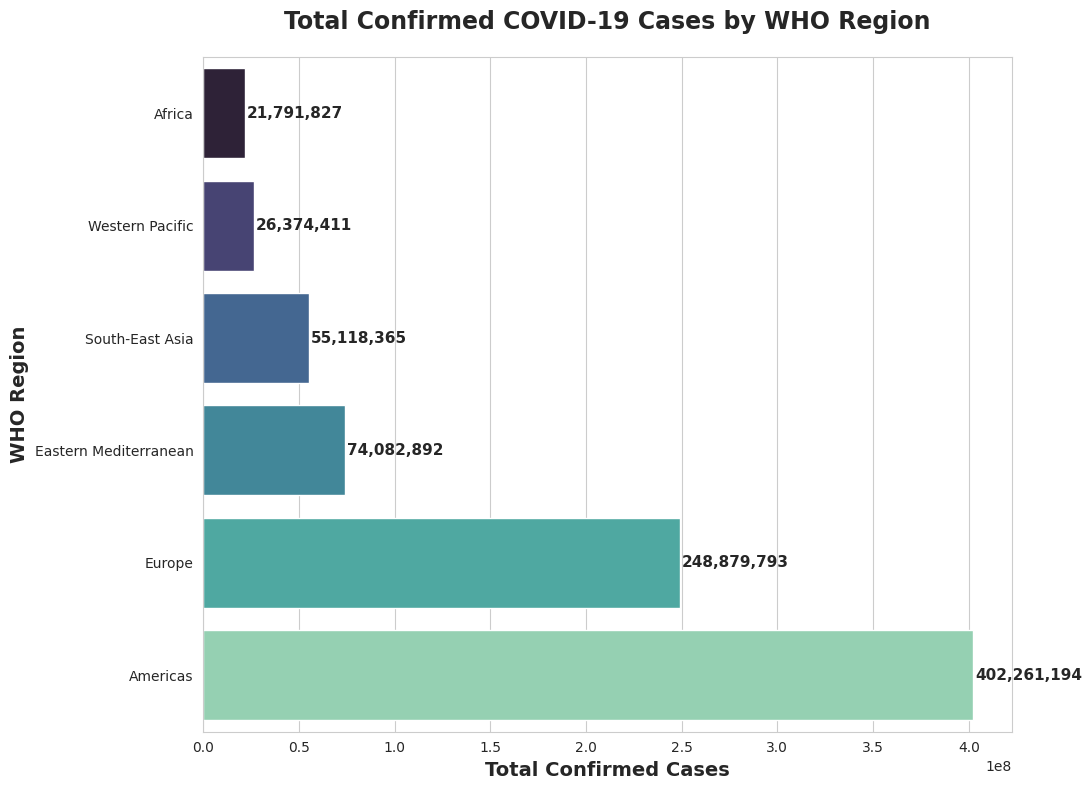

In [91]:
# Aggregate by WHO Region
who_regions = df.groupby('WHO Region')['Confirmed'].sum().reset_index()
who_regions = who_regions.sort_values('Confirmed', ascending=True)

# Create bar chart using seaborn
plt.figure(figsize=(11, 8))
sns.barplot(data=who_regions, y='WHO Region', x='Confirmed',
           palette='mako', orient='h', hue='WHO Region', legend=False)
plt.title('Total Confirmed COVID-19 Cases by WHO Region',
         fontsize=17, fontweight='bold', pad=20)
plt.xlabel('Total Confirmed Cases', fontsize=14, fontweight='bold')
plt.ylabel('WHO Region', fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(who_regions.iterrows()):
    plt.text(row['Confirmed'] + 1000000, i, f"{int(row['Confirmed']):,}",
            va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [92]:
import folium
from folium.plugins import HeatMap

# Select a date for geographic visualization
chosen_date = geo_df['Date'].max()

# Filter data for chosen date
geo_data = geo_df[geo_df['Date'] == chosen_date].copy()
geo_data = geo_data.dropna(subset=['Lat', 'Long'])

# Create base map
base_map = folium.Map(location=[25, 0], zoom_start=2, tiles='Stamen Toner', attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL.')

# Prepare heatmap data with confirmed cases as weight
heatmap_coords = [[row['Lat'], row['Long'], row['Confirmed']]
                  for idx, row in geo_data.iterrows()]

# Add heatmap layer
HeatMap(heatmap_coords, min_opacity=0.25, radius=18, blur=12,
       gradient={0.3: 'blue', 0.5: 'cyan', 0.7: 'yellow', 1: 'red'}).add_to(base_map)

# Add markers for countries with highest cases
top_20 = geo_data.nlargest(20, 'Confirmed')
for idx, row in top_20.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Long']],
        popup=folium.Popup(
            f"<b>{row['Country/Region']}</b><br>"
            f"Confirmed: {row['Confirmed']:,}<br>"
            f"Deaths: {row['Deaths']:,}<br>"
            f"Recovered: {row['Recovered']:,}<br>"
            f"Active: {row['Active']:,}",
            max_width=250
        ),
        icon=folium.Icon(color='darkred', icon='exclamation-triangle', prefix='fa')
    ).add_to(base_map)

base_map

In [93]:
geo_dataset = os.path.join(path, "covid_19_clean_complete.csv")
print("Loading geographic dataset from:", geo_dataset)

geo_df = pd.read_csv(geo_dataset, parse_dates=['Date'])
print("Columns in geo_df:", geo_df.columns.tolist())
geo_df.info()

Loading geographic dataset from: /kaggle/input/corona-virus-report/covid_19_clean_complete.csv
Columns in geo_df: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float6

7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [96]:
import folium
from folium.plugins import MarkerCluster

# Select Western Pacific region
target_region = 'Western Pacific'

# Filter data for Western Pacific
wp_data = geo_df[geo_df['WHO Region'] == target_region].copy()

# Get latest date
latest_date_wp = wp_data['Date'].max()
wp_latest = wp_data[wp_data['Date'] == latest_date_wp]

# Calculate center coordinates
center_lat_wp = wp_latest['Lat'].mean()
center_lon_wp = wp_latest['Long'].mean()

# Create map
wp_map = folium.Map(location=[center_lat_wp, center_lon_wp],
                   zoom_start=4, tiles='OpenStreetMap')

# Create marker cluster
marker_cluster_wp = MarkerCluster().add_to(wp_map)

# Add markers with size based on confirmed cases
max_cases_wp = wp_latest['Confirmed'].max()

for idx, row in wp_latest.iterrows():
    if pd.notna(row['Lat']) and pd.notna(row['Long']):
        # Determine marker size based on cases
        if row['Confirmed'] > max_cases_wp * 0.5:
            icon_color = 'red'
            icon_size = 'large'
        elif row['Confirmed'] > max_cases_wp * 0.2:
            icon_color = 'orange'
            icon_size = 'medium'
        else:
            icon_color = 'green'
            icon_size = 'small'

        folium.Marker(
            location=[row['Lat'], row['Long']],
            popup=folium.Popup(
                f"<b>{row['Country/Region']}</b><br>"
                f"Confirmed: {row['Confirmed']:,}<br>"
                f"Deaths: {row['Deaths']:,}<br>"
                f"Recovered: {row['Recovered']:,}<br>"
                f"Active: {row['Active']:,}",
                max_width=200
            ),
            tooltip=f"{row['Country/Region']}: {row['Confirmed']:,} cases",
            icon=folium.Icon(color=icon_color, icon='info-sign', prefix='fa')
        ).add_to(marker_cluster_wp)

# Add title
title_html = f'''
    <div style="position: fixed;
                top: 10px; left: 50px; width: 400px; height: 60px;
                background-color: white; z-index:9999; font-size:16px;
                border:2px solid grey; padding: 10px">
    <b>COVID-19 Cases in {target_region}</b><br>
    Date: {latest_date_wp}
    </div>
    '''
wp_map.get_root().html.add_child(folium.Element(title_html))

wp_map